In [2]:
import pandas as pd

# 1. Reload fresh data to wipe out the NaNs
df = pd.read_csv('Housing.csv')

# 2. TASK 1: Binary Mapping 
# ONLY apply this to the columns that actually have 'yes' and 'no'
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# 3. TASK 2: One-Hot Encoding
# This handles the 'furnished', 'semi-furnished', etc.
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

# 4. Check the result
print("Clean Data (No more NaNs!):")
print(df.head())

Clean Data (No more NaNs!):
      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0                            False                         Fals

### Model Training and evaluation

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
# --- STEP 1: SPLIT INTO FEATURES (X) AND TARGET (y) ---

x = df.drop('price',axis=1)
y = df['price']

# --- STEP 2: TRAIN-TEST SPLIT (80% Train, 20% Test) ---
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)

# --- STEP 3: SCALING ---

scalar=StandardScaler()
x_train_scaled= scalar.fit_transform(x_train)
x_test_scaled= scalar.transform(x_test)

# --- STEP 4: TRAIN THE MODEL ---
model= LinearRegression()
model.fit(x_train_scaled,y_train)

# --- STEP 5: EVALUATION (THE RESULTS) ---

y_pred = model.predict(x_test_scaled)

print('______MODEL PERFORMANCE_________')
print(f"R-Squared score: {r2_score(y_test,y_pred):.4f}")
print(f"interpretation:Closer to 1.0 is a perfect Model")


______MODEL PERFORMANCE_________
R-Squared score: 0.6529
interpretation:Closer to 1.0 is a perfect Model


In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# 1. Define the 'Settings' we want to test
# n_estimators = number of trees in the forest
# max_depth = how deep each tree can grow
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# 2. Set up the Grid Search (The 'Automatic Tuner')
rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)

# 3. Start the Tuning Process
print("Tuning the model... please wait...")
grid_search.fit(x_train_scaled, y_train)

# 4. Show the Results
print(f"\nBest Settings Found: {grid_search.best_params_}")
best_rf_model = grid_search.best_estimator_
rf_pred = best_rf_model.predict(x_test_scaled)

print(f"Tuned Random Forest R-Squared: {r2_score(y_test, rf_pred):.4f}")

Tuning the model... please wait...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

Best Settings Found: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Tuned Random Forest R-Squared: 0.6018


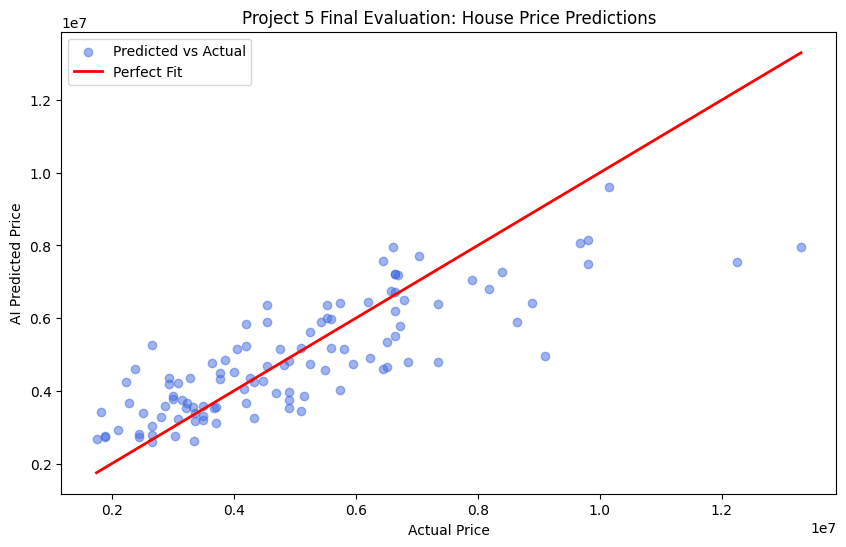

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# We'll plot the Linear Regression results since they were better
plt.scatter(y_test, y_pred, color='royalblue', alpha=0.5, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, label='Perfect Fit')
plt.xlabel('Actual Price')
plt.ylabel('AI Predicted Price')
plt.title('Project 5 Final Evaluation: House Price Predictions')
plt.legend()
plt.show()